# sjov og ballade

In [32]:
from tifffile import imread
import numpy as np
im = imread('/Users/mathildenielsen/Desktop/02506_AIA/week11and12_project/NerveSegmentation/data/nerves_part.tiff')
im_inv = np.invert(im).astype(np.float32)/255
im.shape

(1024, 350, 350)

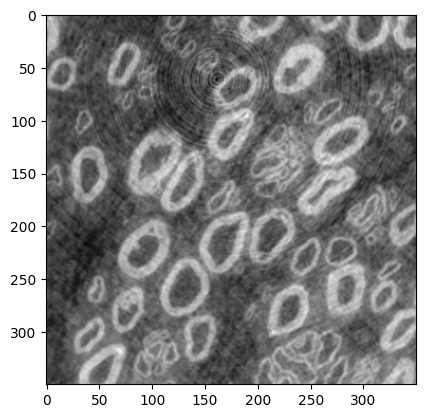

In [18]:
import matplotlib.pyplot as plt

plt.imshow(im[10,:,:])
plt.imshow(im_inv[10,:,:], cmap='gray')

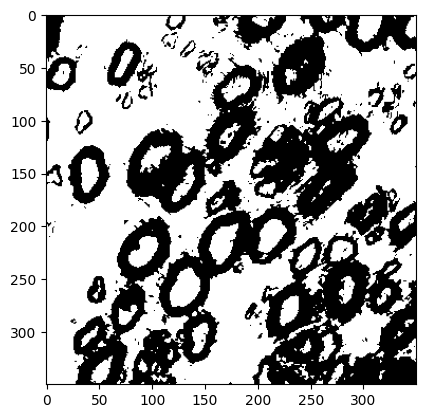

In [14]:
from skimage import data
from skimage.filters import threshold_otsu
thres = threshold_otsu(im)
im_seg = im >thres

plt.imshow(im_seg[10,:,:], cmap='gray')


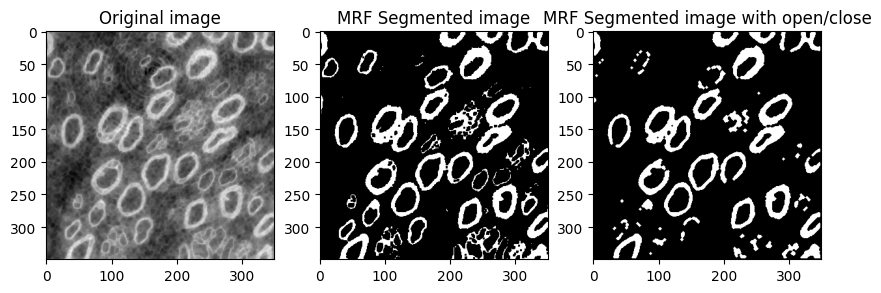

In [167]:
import maxflow
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import grey_closing, grey_erosion, grey_opening, generate_binary_structure
from scipy.ndimage import binary_opening, binary_closing, binary_erosion
def Bin_seg_MRF(img,beta=10, scale=100, mu1_ligt = 90/255.0, mu2_dark = 170/255.0):
    
    footprint = generate_binary_structure(2, 20)
    im_ero2 = grey_erosion(img, footprint=footprint)
    img = im_ero2

    n, m = img.shape

    # Create graph (integer capacities)
    g = maxflow.Graph[int]()
    nodes = g.add_nodes(n * m)
    # Helper: convert (i,j) -> linear index
    def idx(i, j):
        return i * m + j

    # -------------------------
    # Add smoothness edges (4-connected grid)
    # -------------------------
    for i in range(n):
        for j in range(m):

            if i < n - 1:  # edge to pixel below
                g.add_edge(idx(i, j), idx(i+1, j), beta, beta)

            if j < m - 1:  # edge to pixel to the right
                g.add_edge(idx(i, j), idx(i, j+1), beta, beta)

    # -------------------------
    # Add terminal edges (data term)
    # -------------------------
    for i in range(n):
        for j in range(m):
            pixel = img[i, j]
            g.add_tedge(
                idx(i, j),
                int(scale * (pixel - mu2_dark) ** 2),
                int(scale * (pixel - mu1_ligt) ** 2)
            )
    # Run maxflow
    flow = g.maxflow()

    # Retrieve segmentation
    labeling = np.zeros((n, m))

    for i in range(n):
        for j in range(m):
            labeling[i, j] = g.get_segment(idx(i, j))
    
    
    labeling = 1-labeling
    #labeling = np.invert(labeling)
    from scipy.ndimage import binary_opening, binary_closing, binary_erosion
    lab_ero = binary_opening(labeling, iterations=2)
    lab_ero = binary_closing(lab_ero, iterations=1)

    #lab_open = binary_opening(lab_ero)
    #lab_closed = binary_opening(lab_open)


    fig,ax = plt.subplots(1,3, figsize = (10,15))
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("Original image")
    ax[1].imshow(labeling,cmap='gray')
    ax[1].set_title("MRF Segmented image")
    ax[2].imshow(lab_ero,cmap='gray')
    ax[2].set_title("MRF Segmented image with open/close")

    return labeling

nerve_labeled = Bin_seg_MRF(im_inv[0,:,:],beta=0.0008, scale=100, mu1_ligt = 195/255.0, mu2_dark = 120/255.0)

In [ ]:
nerve_labeled = Bin_seg_MRF(im_inv[0,:,:],beta=0.0008, scale=100, mu1_ligt = 195/255.0, mu2_dark = 120/255.0)

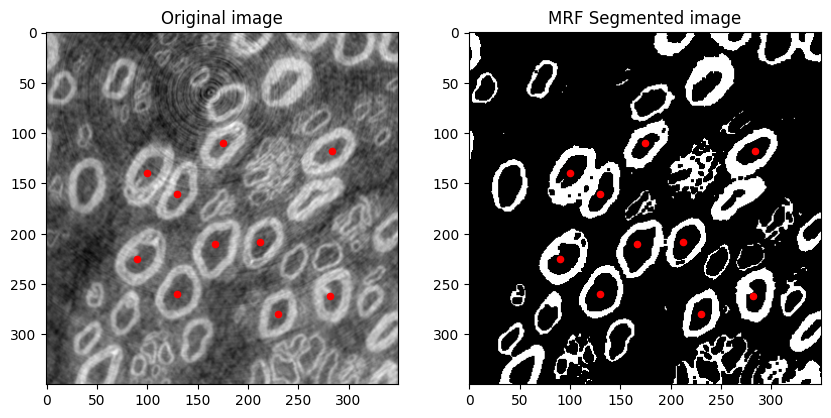

In [156]:
centers = np.array([[130,260],
                    [90,225],
                    [100,140],
                    [130,160],
                    [167,210],
                    [230,280],
                    [175,110],
                    [212,208],
                    [282,262],
                    [284,118]])

fig,ax = plt.subplots(1,2, figsize = (10,15))
ax[0].imshow(im_inv[0,:,:], cmap='gray')
ax[0].set_title("Original image")
ax[1].imshow(nerve_labeled,cmap='gray')
ax[1].set_title("MRF Segmented image")
for c in centers:
    ax[0].scatter(c[0], c[1], marker='o', label='original points', c='r', s=20)
    ax[1].scatter(c[0], c[1], marker='o', label='original points', c='r', s=20)

    

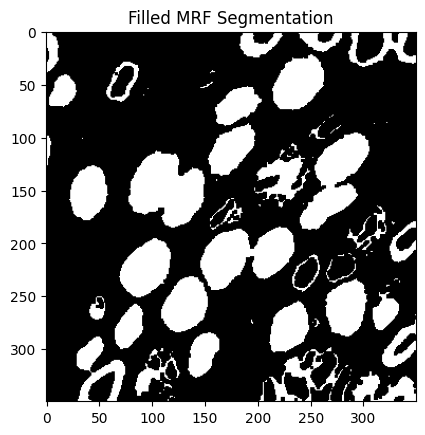

In [157]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

# Assuming 'mrf_image' is your binary image (0 and 1 or 0 and 255)
# If it's a color image, convert it to grayscale/binary first
filled_image = ndimage.binary_fill_holes(nerve_labeled)

plt.imshow(filled_image, cmap='gray')
plt.title("Filled MRF Segmentation")
plt.show()

Text(0.5, 1.0, 'cleaned  image')

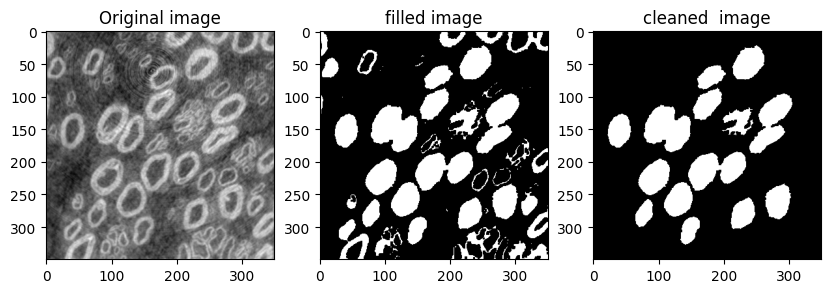

In [170]:
from scipy import ndimage
from skimage import measure, morphology, segmentation
import numpy as np

# 1. Fill the holes
# (Using the image from your screenshot - assume it's loaded as 'mrf_image')
filled = ndimage.binary_fill_holes(nerve_labeled)

# 2. Remove small objects (blobs smaller than 500 pixels)
# morphology.remove_small_objects requires a boolean array
border_cleared = segmentation.clear_border(filled)
cleaned = morphology.remove_small_objects(border_cleared.astype(bool), min_size=700)


# cleaned is now your filtered binary mask
fig,ax = plt.subplots(1,3, figsize = (10,15))
ax[0].imshow(im_inv[0,:,:], cmap='gray')
ax[0].set_title("Original image")
ax[1].imshow(filled,cmap='gray')
ax[1].set_title("filled image")
ax[2].imshow(cleaned,cmap='gray')
ax[2].set_title("cleaned  image")

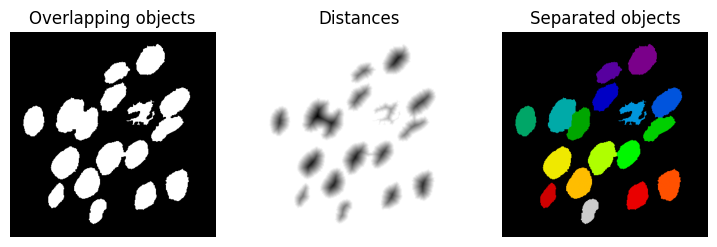

In [184]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.morphology import disk
from skimage.filters import gaussian


# Generate an initial image with two overlapping circles

image = cleaned

# 1. Distance Transform
distance = ndi.distance_transform_edt(image)

# 2. Smooth the distance map to avoid multiple peaks in one blob
# A small sigma (1.0 to 2.0) usually helps significantly
smoothed_distance = gaussian(distance, sigma=0.5)

# 3. Find peaks with a minimum distance between them
# Adjust min_distance based on the radius of your objects
coords = peak_local_max(smoothed_distance, min_distance=10, labels=image)

# 4. Create markers
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)

# 5. Watershed
# Using -smoothed_distance helps the "water" flow into the center of the blobs
labels = watershed(-smoothed_distance, markers, mask=image)
fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)

ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Overlapping objects')
ax[1].imshow(-distance, cmap=plt.cm.gray)
ax[1].set_title('Distances')
ax[2].imshow(labels, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Separated objects')

for a in ax:
    a.set_axis_off()


## extra

Text(0.5, 1.0, 'MRF Segmented image with open/close')

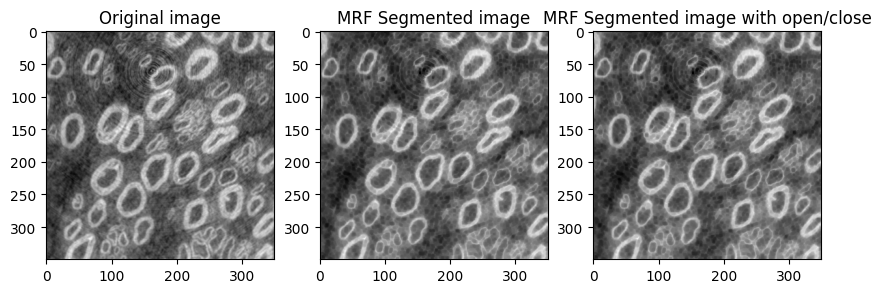

In [105]:
from scipy.ndimage import grey_closing, grey_erosion, grey_opening, generate_binary_structure
footprint = generate_binary_structure(2, 10)
im_ero = grey_erosion(im_inv[0,:,:], footprint=footprint)
footprint = generate_binary_structure(2, 20)
im_ero2 = grey_erosion(im_inv[0,:,:], footprint=footprint)

fig,ax = plt.subplots(1,3, figsize = (10,15))
ax[0].imshow(im_inv[0,:,:], cmap='gray')
ax[0].set_title("Original image")
ax[1].imshow(im_ero,cmap='gray')
ax[1].set_title("MRF Segmented image")
ax[2].imshow(im_ero2,cmap='gray')
ax[2].set_title("MRF Segmented image with open/close")

Text(0.5, 1.0, 'MRF Segmented image')

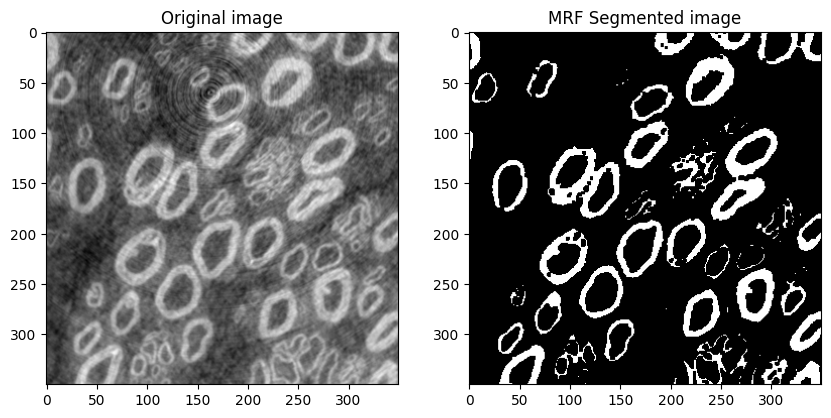

In [103]:
np.min(im_ero)

t = threshold_otsu(im_ero)
seg_ero = im_ero>t+0.1
fig,ax = plt.subplots(1,2, figsize = (10,15))
ax[0].imshow(im_inv[0,:,:], cmap='gray')
ax[0].set_title("Original image")
ax[1].imshow(seg_ero,cmap='gray')
ax[1].set_title("MRF Segmented image")
